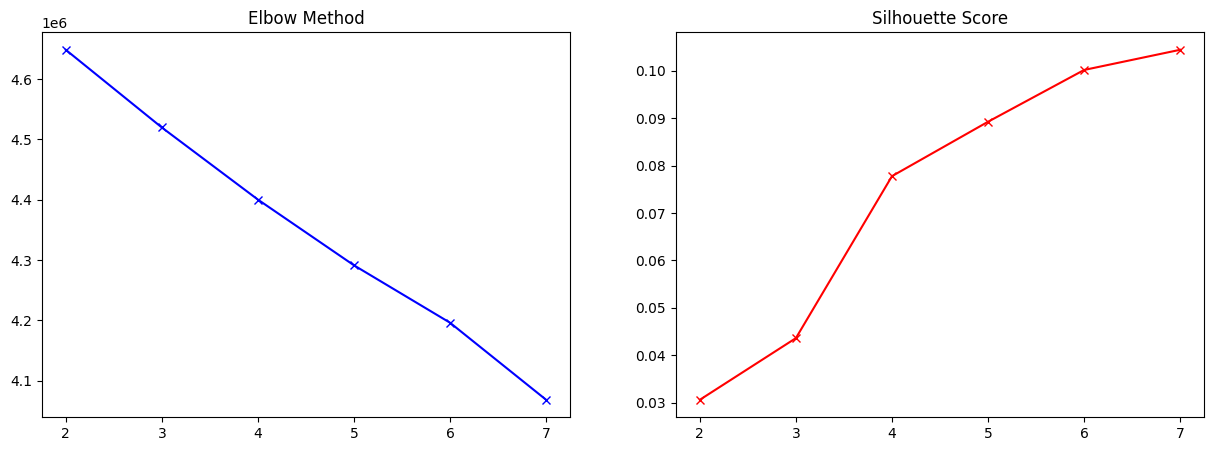


--- Patient Personas by Cluster ---
           target  number_diagnoses  number_inpatient  num_medications  \
cluster                                                                  
0        0.108737          7.275085          0.660522        15.355975   
1        0.111264          7.506095          0.605703        17.150770   
2        0.117731          7.651795          0.610365        16.407818   

         time_in_hospital  
cluster                    
0                4.306144  
1                4.382685  
2                4.590878  


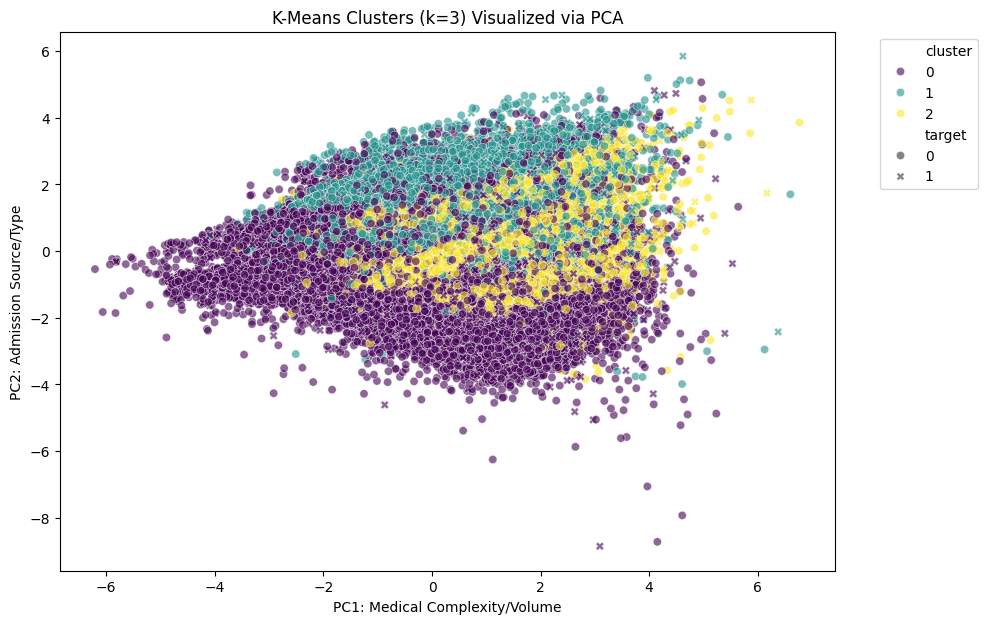

In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

#load and clean
np.random.seed(1118)
df_raw = pd.read_csv('sample_data/diabetic_data.csv')
df_raw.replace('?', np.nan, inplace=True)

#define target
target_map = {'NO': 0, '<30': 1, '>30': 0}
df_raw['target'] = df_raw['readmitted'].map(target_map)

#refined feature selection and proper encoding
#We explicitly treat IDs as strings so get_dummies handles them correctly
features = [
    "age", "number_diagnoses", "time_in_hospital", "num_medications",
    "number_inpatient", "number_emergency", "number_outpatient",
    "discharge_disposition_id", "admission_type_id"
]

df = df_raw[features + ["target"]].dropna().copy()
df['admission_type_id'] = df['admission_type_id'].astype(str)
df['discharge_disposition_id'] = df['discharge_disposition_id'].astype(str)

#one-hot encode all categorical features
df = pd.get_dummies(df, columns=["age", "admission_type_id", "discharge_disposition_id"], drop_first=True)


X = df.drop("target", axis=1)
#using StandardScaler because K-Means is sensitive to the scale of features like num_medications
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



#enhanced cluster validation using both Elbow and Silhouette
inertia = []
sil_scores = []
K = range(2, 8)

#I chose K-Means Clustering to identify natural patient profiles that might not be obvious through supervised labels alone.
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    score = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    sil_scores.append(score)

#plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(K, inertia, 'bx-')
ax1.set_title('Elbow Method')
ax2.plot(K, sil_scores, 'rx-')
ax2.set_title('Silhouette Score')
plt.show()

#final model based on elbow method
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

#profiling: we use more features here to describe the groups
profile_cols = ['target', 'number_diagnoses', 'number_inpatient', 'num_medications', 'time_in_hospital']
cluster_profiles = df.groupby('cluster')[profile_cols].mean()
print("\n--- Patient Personas by Cluster ---")
print(cluster_profiles)

#PCA for dimensiality
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

#visualization
plt.figure(figsize=(10, 7))
sns.scatterplot(x=components[:,0], y=components[:,1], hue=df['cluster'],
                style=df['target'], palette='viridis', alpha=0.6)
plt.title(f'K-Means Clusters (k={optimal_k}) Visualized via PCA')
plt.xlabel(f'PC1: Medical Complexity/Volume')
plt.ylabel(f'PC2: Admission Source/Type')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()